In [1]:
# 라이브러리 불러오기
from selenium import webdriver as wb # web browser
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.common.by import By
import time
import pandas as pd
import re
from tqdm import tqdm

# 문자열 전처리 함수 -> 숫자, 문자, 특수문자 제외하고 삭제
def preprocess_sentence_kr(w):
  w = w.strip()
  w = re.sub(r"[^0-9가-힣?.!,¿]+", " ", w) 
  w = w.strip() 
  return w

In [2]:
# 네이버 메인페이지 -> "음식물 처리기" 검색 -> 지식인 탭 클릭

driver = wb.Chrome()
driver.get('https://www.naver.com/') 

In [3]:
s = driver.find_element(By.ID, 'query')
s.send_keys('LG전자 신혼'+'\n') # \n 브라우저 입장에서는 Enter 키로 인식

In [4]:
# 블로그 탭 클릭
in_click = driver.find_element(By.CSS_SELECTOR, '#lnb > div.lnb_group > div > div.lnb_nav_area._nav_area_root > div > div.api_flicking_wrap._conveyer_root > div:nth-child(1) > a')
in_click.click()

- 기간 설정을 통하여 6개월 이내의 데이터만 노출

In [5]:
# 기간값을 가진 요소 추출 -> 클릭
option_btn = driver.find_element(By.CSS_SELECTOR, '#snb > div.mod_group_option_filter._search_option_simple_wrap > div > div.option_filter > a')
option_btn.click()
time.sleep(1)

In [6]:
# 기간값을 가진 요소 추출 -> 클릭
option_btn = driver.find_element(By.CSS_SELECTOR, '#snb > div.mod_group_option_sort._search_option_detail_wrap > ul > li.bx.term > div > div.option > a:nth-child(8)')
option_btn.click()
time.sleep(1)

In [7]:
# 스크롤 내리기 (전체화면(body)에 END 키를 전송)
for i in range(10):
    body = driver.find_element(By.TAG_NAME, 'body')
    body.send_keys(Keys.END)
    time.sleep(1)

In [8]:
# 블로그 게시글 url 수집
urls = driver.find_elements(By.CSS_SELECTOR, 'a.ialLiYPc7XEN3dJ4Tujv.pHHExKwXvRWn4fm5O0Hr')

# href 데이터만 리스트에 저장 (href_list)
# 요소.get_attribute('href')
href_list = [url.get_attribute('href') for url in urls]
title_list = [url.text for url in urls]

print(len(href_list))
print(href_list[0])

print(len(title_list))
print(title_list[0])

330
https://blog.naver.com/kmihi1211/224038925149
330
LG전자 베스트샵 동탄본점에서 신혼가전 준비하기


In [9]:
# 1개 url에 대해서 우선 진행

driver.get(href_list[0])
time.sleep(1)

driver.switch_to.frame('mainFrame')
contents = driver.find_element(By.CSS_SELECTOR, 'div.se-main-container')
contents.text

"이번에 새 집으로 이사를 가게 되면서\n노후된 가전제품을 대부분 버리게 되었어요.\n냉장고, 세탁기, 식세기, 인덕션까지 새로 다\n한 번에 맞춰야 하는데\n가전이 한두푼도 아니고 가격대가 높은데\n색감이나 디자인을 온라인에서만 보기가 애매하더라구요.\n그렇다고 이곳저곳 다니면서 발품팔기는 시간이 없고\n그래서 LG전자 베스트샵 동탄본점을 다녀왔는데\n가전이 다 모여있어서 비교하고 한곳에서 실물 확인할 수 있어서 마음에 들었고\n직원분들이 친절하게 안내해주셔서 편하게 둘러보고 왔어요!\n저처럼 신혼집 꾸미는 분들께 도움이 되길 바라며🙏🏻\n포스팅 시작할게요 :)\n📍LG전자 베스트샵 동탄본점\n주소 경기 화성시 동탄대로 557-9\n연락처 031-831-8027\n영업시간 10:30 -20:30 (일요일 상이)\n주차장 지하주차장\n1. 위치/주차/분위기\nLG전자 베스트샵 동탄본점은 동탄역 근처라\n지하철이나 자차로 가기에도 편했어요.\n주차는 지하에 하고 올라갔고, 나올 때 주차등록을 부탁드리니 바로 해주셨어요.\n직원분들이 먼저 밝게 인사해주고 친절하게 안내해줘서\n기분좋게 둘러보고 왔어요.\n1층엔 LG그램 노트북, LG 올레드TV가 진열돼 있고,\n마침 입주이사 특별세일도 진행 중이라 그런지\n사람이 꽤 많았는데도 매장이 넓어서 붐비지 않았어요.\n디피된 제품들도 정갈하게 정리되어 있어서\n여러가지 제품 보면서 하나하나 비교하기에 딱 좋았어요.\n2. 가전제품 둘러보기\n제일 먼저 눈에 띈 건 LG 디오스 오브제컬렉션 노크온 매직스페이스 냉장고!\n사실 온라인으로만 봤을 땐 컬러 고민이 많았는데\n직접 보니까 확실히 감이 잡히더라구요.\n유광이나 무광 컬러 질감 차이도 바로 비교 가능했고,\n무엇보다 내가 원하는 색 조합으로 만들 수 있다는 점이\n너무 매력적이었어요.\n특히 노크온 매직스페이스는 문을 열지 않아도\n살짝 노크하면 내부가 보여서 냉기 손실 없이 실용적이에요.\n저처럼 커피·음료 자주 마시는 분들은\nLG 디오스 오브제컬렉션 STEM 

In [10]:
# 1. 확보된 url 주소를 통해 반복적으로 요청
# 2. 게시글 내 작성된 리뷰를 추출하여 텍스트 파일로 저장
# 파일명: 네이버 지식인 리뷰 데이터.txt

driver = wb.Chrome()
time.sleep(2)

f = open('./data/네이버 블로그_LG전자+신혼 데이터.txt', 'w', encoding='utf-8')

for href in tqdm(href_list):
    driver.get(href)
    time.sleep(1)
    driver.switch_to.frame('mainFrame')
    time.sleep(1)
    
    contents = driver.find_element(By.CSS_SELECTOR, 'div.se-main-container')
    contents_preprocessed = preprocess_sentence_kr(contents.text)
    f.write(contents_preprocessed)
    
    # print('-'*50)
f.close()

100%|██████████| 330/330 [20:51<00:00,  3.79s/it]


- 수집된 데이터 시각화
- 워드클라우드
    - kiwi 라이브러리 활용하여 토큰화
    - 빈도수 상위 100개 단어 활용하여 워드클라우드 생성

In [11]:
# 라이브러리 불러오기
from kiwipiepy import Kiwi # 형태소 분석기
from collections import Counter # 단어가 나온 횟수를 셈
from wordcloud import WordCloud # 워드클라우드 생성 도구
import matplotlib.pyplot as plt # 시각화 도구
from PIL import Image
import numpy as np

In [12]:
f = open('./data/네이버 블로그_LG전자+신혼 데이터.txt', 'r', encoding='utf-8')
review = f.read()
f.close()
print(len(review))

697508


In [13]:
# 도구 객체생성
kiwi = Kiwi()

# 토큰화
token = kiwi.tokenize(review)
token

# form: 토큰화 결과
# tag: 품사 태크
# nnp: 고유명사; nng: 일반명사

[Token(form='이번', tag='NNG', start=0, len=2),
 Token(form='에', tag='JKB', start=2, len=1),
 Token(form='새', tag='MM', start=4, len=1),
 Token(form='집', tag='NNG', start=6, len=1),
 Token(form='으로', tag='JKB', start=7, len=2),
 Token(form='이사', tag='NNG', start=10, len=2),
 Token(form='를', tag='JKO', start=12, len=1),
 Token(form='가', tag='VV', start=14, len=1),
 Token(form='게', tag='EC', start=15, len=1),
 Token(form='되', tag='VV', start=17, len=1),
 Token(form='면서', tag='EC', start=18, len=2),
 Token(form='노후', tag='NNG', start=21, len=2),
 Token(form='되', tag='XSV', start=23, len=1),
 Token(form='ᆫ', tag='ETM', start=23, len=1),
 Token(form='가전', tag='NNG', start=25, len=2),
 Token(form='제품', tag='NNG', start=27, len=2),
 Token(form='을', tag='JKO', start=29, len=1),
 Token(form='대부분', tag='NNG', start=31, len=3),
 Token(form='버리', tag='VV', start=35, len=2),
 Token(form='게', tag='EC', start=37, len=1),
 Token(form='되', tag='VV', start=39, len=1),
 Token(form='었', tag='EP', start=40, 

In [14]:
# 일반명사만 추출 (NNG)
# 리스트명 = [실행문 반복문 조건]
# nng_token = [t.form for t in token if t.tag=='NNG']
nng_token = [t.form for t in token if t.tag=='NNG' or t.tag=='NNP']

print(len(nng_token))
print(nng_token)

118857
['이번', '집', '이사', '노후', '가전', '제품', '대부분', '냉장고', '세탁기', '식', '세기', '인덕션', '가전', '가격대', '색감', '디자인', '온라인', '애매', '이곳저곳', '발품', '시간', '전자', '베스트', '샵', '동탄', '본점', '가전', '비교', '곳', '실물', '확인', '마음', '직원', '친절', '안내', '신혼', '집', '도움', '포스팅', '시작', '전자', '베스트', '샵', '동탄', '본점', '주소', '경기', '화성시', '동탄', '연락처', '영업시간', '일요일', '상', '주차장', '지하', '주차장', '위치', '주차', '분위기', '전자', '베스트', '샵', '동탄', '본점', '동탄', '역', '근처', '지하철', '자차', '주차', '지하', '때', '주차', '등록', '부탁', '직원', '인사', '친절', '안내', '기분', '층', '노트북', '레드', '진열', '입주', '이사', '세일', '진행', '사람', '매장', '디피', '제품', '정리', '제품', '비교', '가전제품', '눈', '디오스', '오브제', '컬렉션', '노크', '매직', '스페이스', '냉장고', '온라인', '때', '컬러', '고민', '감', '유광', '광', '컬러', '질감', '차이', '비교', '가능', '색', '조합', '점', '매력', '노크', '매직', '스페이스', '문', '노크', '내부', '냉기', '손실', '실용', '커피', '음료', '디오스', '오브제', '컬렉션', '얼음', '정수', '냉장고', '만족', '요즘', '맞벌이', '부부', '필수템', '디오스', '오브제', '컬렉션', '식기세척기', '회사', '설거지', '스트레스', '부부', '사이', '시간', '휴식', '식', '세기', '친구', '식기세척기', '위', '시', '리스트', 

In [15]:
# 2글자 이상의 단어만 추출
nng_token2 = [t for t in nng_token if len(t)>=2]
nng_token2

['이번',
 '이사',
 '노후',
 '가전',
 '제품',
 '대부분',
 '냉장고',
 '세탁기',
 '세기',
 '인덕션',
 '가전',
 '가격대',
 '색감',
 '디자인',
 '온라인',
 '애매',
 '이곳저곳',
 '발품',
 '시간',
 '전자',
 '베스트',
 '동탄',
 '본점',
 '가전',
 '비교',
 '실물',
 '확인',
 '마음',
 '직원',
 '친절',
 '안내',
 '신혼',
 '도움',
 '포스팅',
 '시작',
 '전자',
 '베스트',
 '동탄',
 '본점',
 '주소',
 '경기',
 '화성시',
 '동탄',
 '연락처',
 '영업시간',
 '일요일',
 '주차장',
 '지하',
 '주차장',
 '위치',
 '주차',
 '분위기',
 '전자',
 '베스트',
 '동탄',
 '본점',
 '동탄',
 '근처',
 '지하철',
 '자차',
 '주차',
 '지하',
 '주차',
 '등록',
 '부탁',
 '직원',
 '인사',
 '친절',
 '안내',
 '기분',
 '노트북',
 '레드',
 '진열',
 '입주',
 '이사',
 '세일',
 '진행',
 '사람',
 '매장',
 '디피',
 '제품',
 '정리',
 '제품',
 '비교',
 '가전제품',
 '디오스',
 '오브제',
 '컬렉션',
 '노크',
 '매직',
 '스페이스',
 '냉장고',
 '온라인',
 '컬러',
 '고민',
 '유광',
 '컬러',
 '질감',
 '차이',
 '비교',
 '가능',
 '조합',
 '매력',
 '노크',
 '매직',
 '스페이스',
 '노크',
 '내부',
 '냉기',
 '손실',
 '실용',
 '커피',
 '음료',
 '디오스',
 '오브제',
 '컬렉션',
 '얼음',
 '정수',
 '냉장고',
 '만족',
 '요즘',
 '맞벌이',
 '부부',
 '필수템',
 '디오스',
 '오브제',
 '컬렉션',
 '식기세척기',
 '회사',
 '설거지',
 '스트레스',
 '부부',
 '사이',
 '시간',
 '휴식',
 '세기',

In [16]:
# 명사의 개수를 세서 많이 나오는 단어를 활용하여 워드클라욷 생성하기
counter = Counter(nng_token2)
counter

Counter({'가전': 5341,
         '전자': 4550,
         '베스트': 3072,
         '신혼': 2031,
         '제품': 1938,
         '혜택': 1761,
         '매장': 1342,
         '상담': 1331,
         '구매': 1154,
         '다양': 1052,
         '방문': 1051,
         '할인': 855,
         '예약': 833,
         '구독': 801,
         '냉장고': 778,
         '본점': 734,
         '이사': 731,
         '준비': 702,
         '혼수': 696,
         '가능': 695,
         '진행': 649,
         '행사': 614,
         '공간': 554,
         '추천': 523,
         '이벤트': 522,
         '세탁기': 509,
         '웨딩': 508,
         '효율': 479,
         '오브제': 464,
         '오픈': 463,
         '서비스': 463,
         '확인': 459,
         '입주': 452,
         '사용': 450,
         '선택': 417,
         '청소기': 415,
         '컬렉션': 414,
         '가전제품': 409,
         '에어컨': 408,
         '신혼부부': 404,
         '견적': 397,
         '필요': 394,
         '요즘': 391,
         '정보': 377,
         '생각': 366,
         '가격': 364,
         '체험': 357,
         '비교': 353,
         '울산': 3

In [17]:
# 상위 100개 단어만 추출
top_100 = counter.most_common(100)
top_100

[('가전', 5341),
 ('전자', 4550),
 ('베스트', 3072),
 ('신혼', 2031),
 ('제품', 1938),
 ('혜택', 1761),
 ('매장', 1342),
 ('상담', 1331),
 ('구매', 1154),
 ('다양', 1052),
 ('방문', 1051),
 ('할인', 855),
 ('예약', 833),
 ('구독', 801),
 ('냉장고', 778),
 ('본점', 734),
 ('이사', 731),
 ('준비', 702),
 ('혼수', 696),
 ('가능', 695),
 ('진행', 649),
 ('행사', 614),
 ('공간', 554),
 ('추천', 523),
 ('이벤트', 522),
 ('세탁기', 509),
 ('웨딩', 508),
 ('효율', 479),
 ('오브제', 464),
 ('오픈', 463),
 ('서비스', 463),
 ('확인', 459),
 ('입주', 452),
 ('사용', 450),
 ('선택', 417),
 ('청소기', 415),
 ('컬렉션', 414),
 ('가전제품', 409),
 ('에어컨', 408),
 ('신혼부부', 404),
 ('견적', 397),
 ('필요', 394),
 ('요즘', 391),
 ('정보', 377),
 ('생각', 366),
 ('가격', 364),
 ('체험', 357),
 ('비교', 353),
 ('울산', 352),
 ('결혼', 350),
 ('으뜸', 339),
 ('구경', 336),
 ('위치', 330),
 ('건조기', 330),
 ('카드', 329),
 ('플래그', 317),
 ('전시', 312),
 ('매니저', 311),
 ('기능', 309),
 ('고민', 306),
 ('환급', 301),
 ('홈플러스', 295),
 ('디자인', 293),
 ('인테리어', 292),
 ('후기', 284),
 ('고객', 283),
 ('주차', 282),
 ('설명', 282),
 ('멤버십', 280),
 

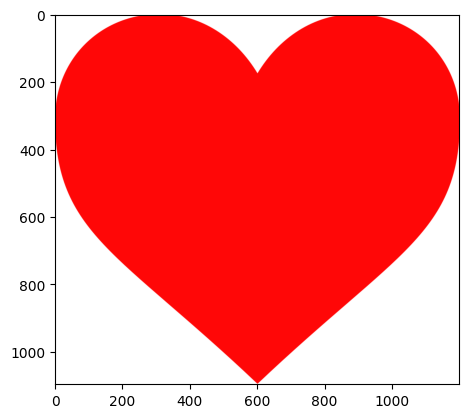

In [18]:
icon = Image.open('./data/heart.png')    # 마스크가 될 이미지 불러오기 
# plt.imshow(icon)

mask = Image.new("RGB", icon.size, (255,255,255))

mask.paste(icon,icon)
mask = np.array(mask)
plt.imshow(mask)

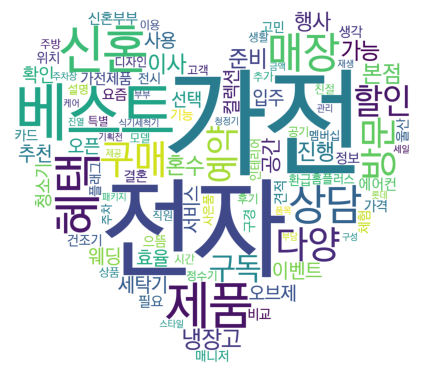

In [19]:
# WordCloud(): 스타일(배경,글꼴), 최대단어수, 마스크이미지 등 옵션을 설정
# generate_from_frequencies(): 미리 정의된 단어의 빈도수를 이용해서 워드클라우드 이미지를 생성

wc = WordCloud(
    font_path='C:/Windows/Fonts/LG PC.ttf', # malgunbd.ttf
    background_color='white',
    mask=mask
        
).generate_from_frequencies(dict(top_100))

plt.imshow(wc)
plt.axis('off')
plt.show()